In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

In [3]:
# ============================================================
# КОНФИГИ
# ============================================================
TRAIN_DIR = '/kaggle/input/competitions/dl-lab-4-ocr/train/train'
TEST_DIR  = '/kaggle/input/competitions/dl-lab-4-ocr/test/test'
TRAIN_CSV = '/kaggle/input/competitions/dl-lab-4-ocr/train.csv'

In [4]:
# ============================================================
# УТИЛИТЫ
# ============================================================
def load_image(path: str) -> np.ndarray:
    """Загружает изображение через cv2, возвращает RGB."""
    img = cv2.imdecode(np.fromfile(path, dtype=np.uint8), cv2.IMREAD_COLOR)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def collect_sizes(directory: str) -> pd.DataFrame:
    """Собирает (filename, width, height) для всех jpg в папке."""
    records = []
    for fname in os.listdir(directory):
        if not fname.lower().endswith('.jpg'):
            continue
        path = os.path.join(directory, fname)
        img  = cv2.imdecode(np.fromfile(path, dtype=np.uint8), cv2.IMREAD_UNCHANGED)
        if img is None:
            continue
        h, w = img.shape[:2]
        records.append({'filename': fname, 'width': w, 'height': h, 'pixels': w * h})
    return pd.DataFrame(records)


def print_size_stats(df: pd.DataFrame, tag: str) -> None:
    """Печатает сводную статистику размеров."""
    print(f"\n{'='*50}")
    print(f"  Статистика размеров — {tag}")
    print(f"{'='*50}")
    for dim in ('width', 'height', 'pixels'):
        s = df[dim]
        print(f"\n  [{dim}]")
        print(f"    Кол-во  : {len(s)}")
        print(f"    Среднее : {s.mean():.1f}")
        print(f"    Медиана : {s.median():.1f}")
        print(f"    Мин     : {s.min()}")
        print(f"    Макс    : {s.max()}")
        print(f"    75%     : {s.quantile(0.75):.1f}")
        print(f"    95%     : {s.quantile(0.95):.1f}")


def plot_image_grid(image_paths: list, titles: list, tag: str,
                    nrows: int = 10, ncols: int = 10) -> None:
    """Выводит сетку nrows×ncols изображений с подписями."""
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.8, nrows * 2.0))
    fig.suptitle(f'{tag}  —  первые {nrows*ncols} изображений',
                 fontsize=14, fontweight='bold', y=1.01)

    for i, ax in enumerate(axes.flat):
        if i < len(image_paths):
            img = load_image(image_paths[i])
            ax.imshow(img)
            ax.set_title(str(titles[i]), fontsize=8, pad=2)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


def plot_size_histograms(df: pd.DataFrame, tag: str) -> None:
    """Гистограммы ширины, высоты и площади."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f'Распределение размеров — {tag}', fontsize=13, fontweight='bold')

    dims   = ('width',       'height',      'pixels')
    labels = ('Ширина (px)', 'Высота (px)', 'Площадь (px²)')
    colors = ('#4C72B0',     '#DD8452',     '#55A868')

    for ax, dim, label, color in zip(axes, dims, labels, colors):
        data = df[dim]
        ax.hist(data, bins=40, color=color, edgecolor='white', linewidth=0.5)
        ax.axvline(data.mean(),            color='red',    ls='--', lw=1.5, label=f'mean={data.mean():.0f}')
        ax.axvline(data.median(),          color='black',  ls='-',  lw=1.5, label=f'median={data.median():.0f}')
        ax.axvline(data.quantile(0.75),    color='purple', ls=':',  lw=1.5, label=f'p75={data.quantile(0.75):.0f}')
        ax.axvline(data.quantile(0.95),    color='orange', ls=':',  lw=1.5, label=f'p95={data.quantile(0.95):.0f}')
        ax.set_xlabel(label)
        ax.set_ylabel('Количество')
        ax.legend(fontsize=7)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_price_distribution(train_csv: str) -> None:
    """Гистограмма распределения цен в тренировочном датасете."""
    df = pd.read_csv(train_csv)
    prices = df['Price']

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Распределение цен — train.csv', fontsize=13, fontweight='bold')

    # --- Гистограмма ---
    ax = axes[0]
    ax.hist(prices, bins=60, color='#4C72B0', edgecolor='white', linewidth=0.5)
    ax.axvline(prices.mean(),         color='red',    ls='--', lw=1.5, label=f'mean={prices.mean():.1f}')
    ax.axvline(prices.median(),       color='black',  ls='-',  lw=1.5, label=f'median={prices.median():.1f}')
    ax.axvline(prices.quantile(0.75), color='purple', ls=':',  lw=1.5, label=f'p75={prices.quantile(0.75):.1f}')
    ax.axvline(prices.quantile(0.95), color='orange', ls=':',  lw=1.5, label=f'p95={prices.quantile(0.95):.1f}')
    ax.set_xlabel('Цена')
    ax.set_ylabel('Количество изображений')
    ax.set_title('Гистограмма цен')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    # --- Топ-20 самых частых цен ---
    ax2 = axes[1]
    top20 = prices.value_counts().head(20)
    ax2.bar(top20.index.astype(str), top20.values, color='#DD8452', edgecolor='white')
    ax2.set_xlabel('Цена')
    ax2.set_ylabel('Количество')
    ax2.set_title('Топ-20 самых частых цен')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # --- Текстовая статистика ---
    print(f"\n{'='*50}")
    print(f"  Статистика цен — train.csv")
    print(f"{'='*50}")
    print(f"  Записей всего    : {len(prices)}")
    print(f"  Уникальных цен   : {prices.nunique()}")
    print(f"  Среднее          : {prices.mean():.2f}")
    print(f"  Медиана          : {prices.median():.1f}")
    print(f"  Мин              : {prices.min()}")
    print(f"  Макс             : {prices.max()}")
    print(f"  75%              : {prices.quantile(0.75):.1f}")
    print(f"  95%              : {prices.quantile(0.95):.1f}")
    print(f"\n  Топ-10 цен:")
    print(prices.value_counts().head(10).to_string())

>>> Загружаем train.csv ...
>>> Рисуем сетку тренировочных изображений ...


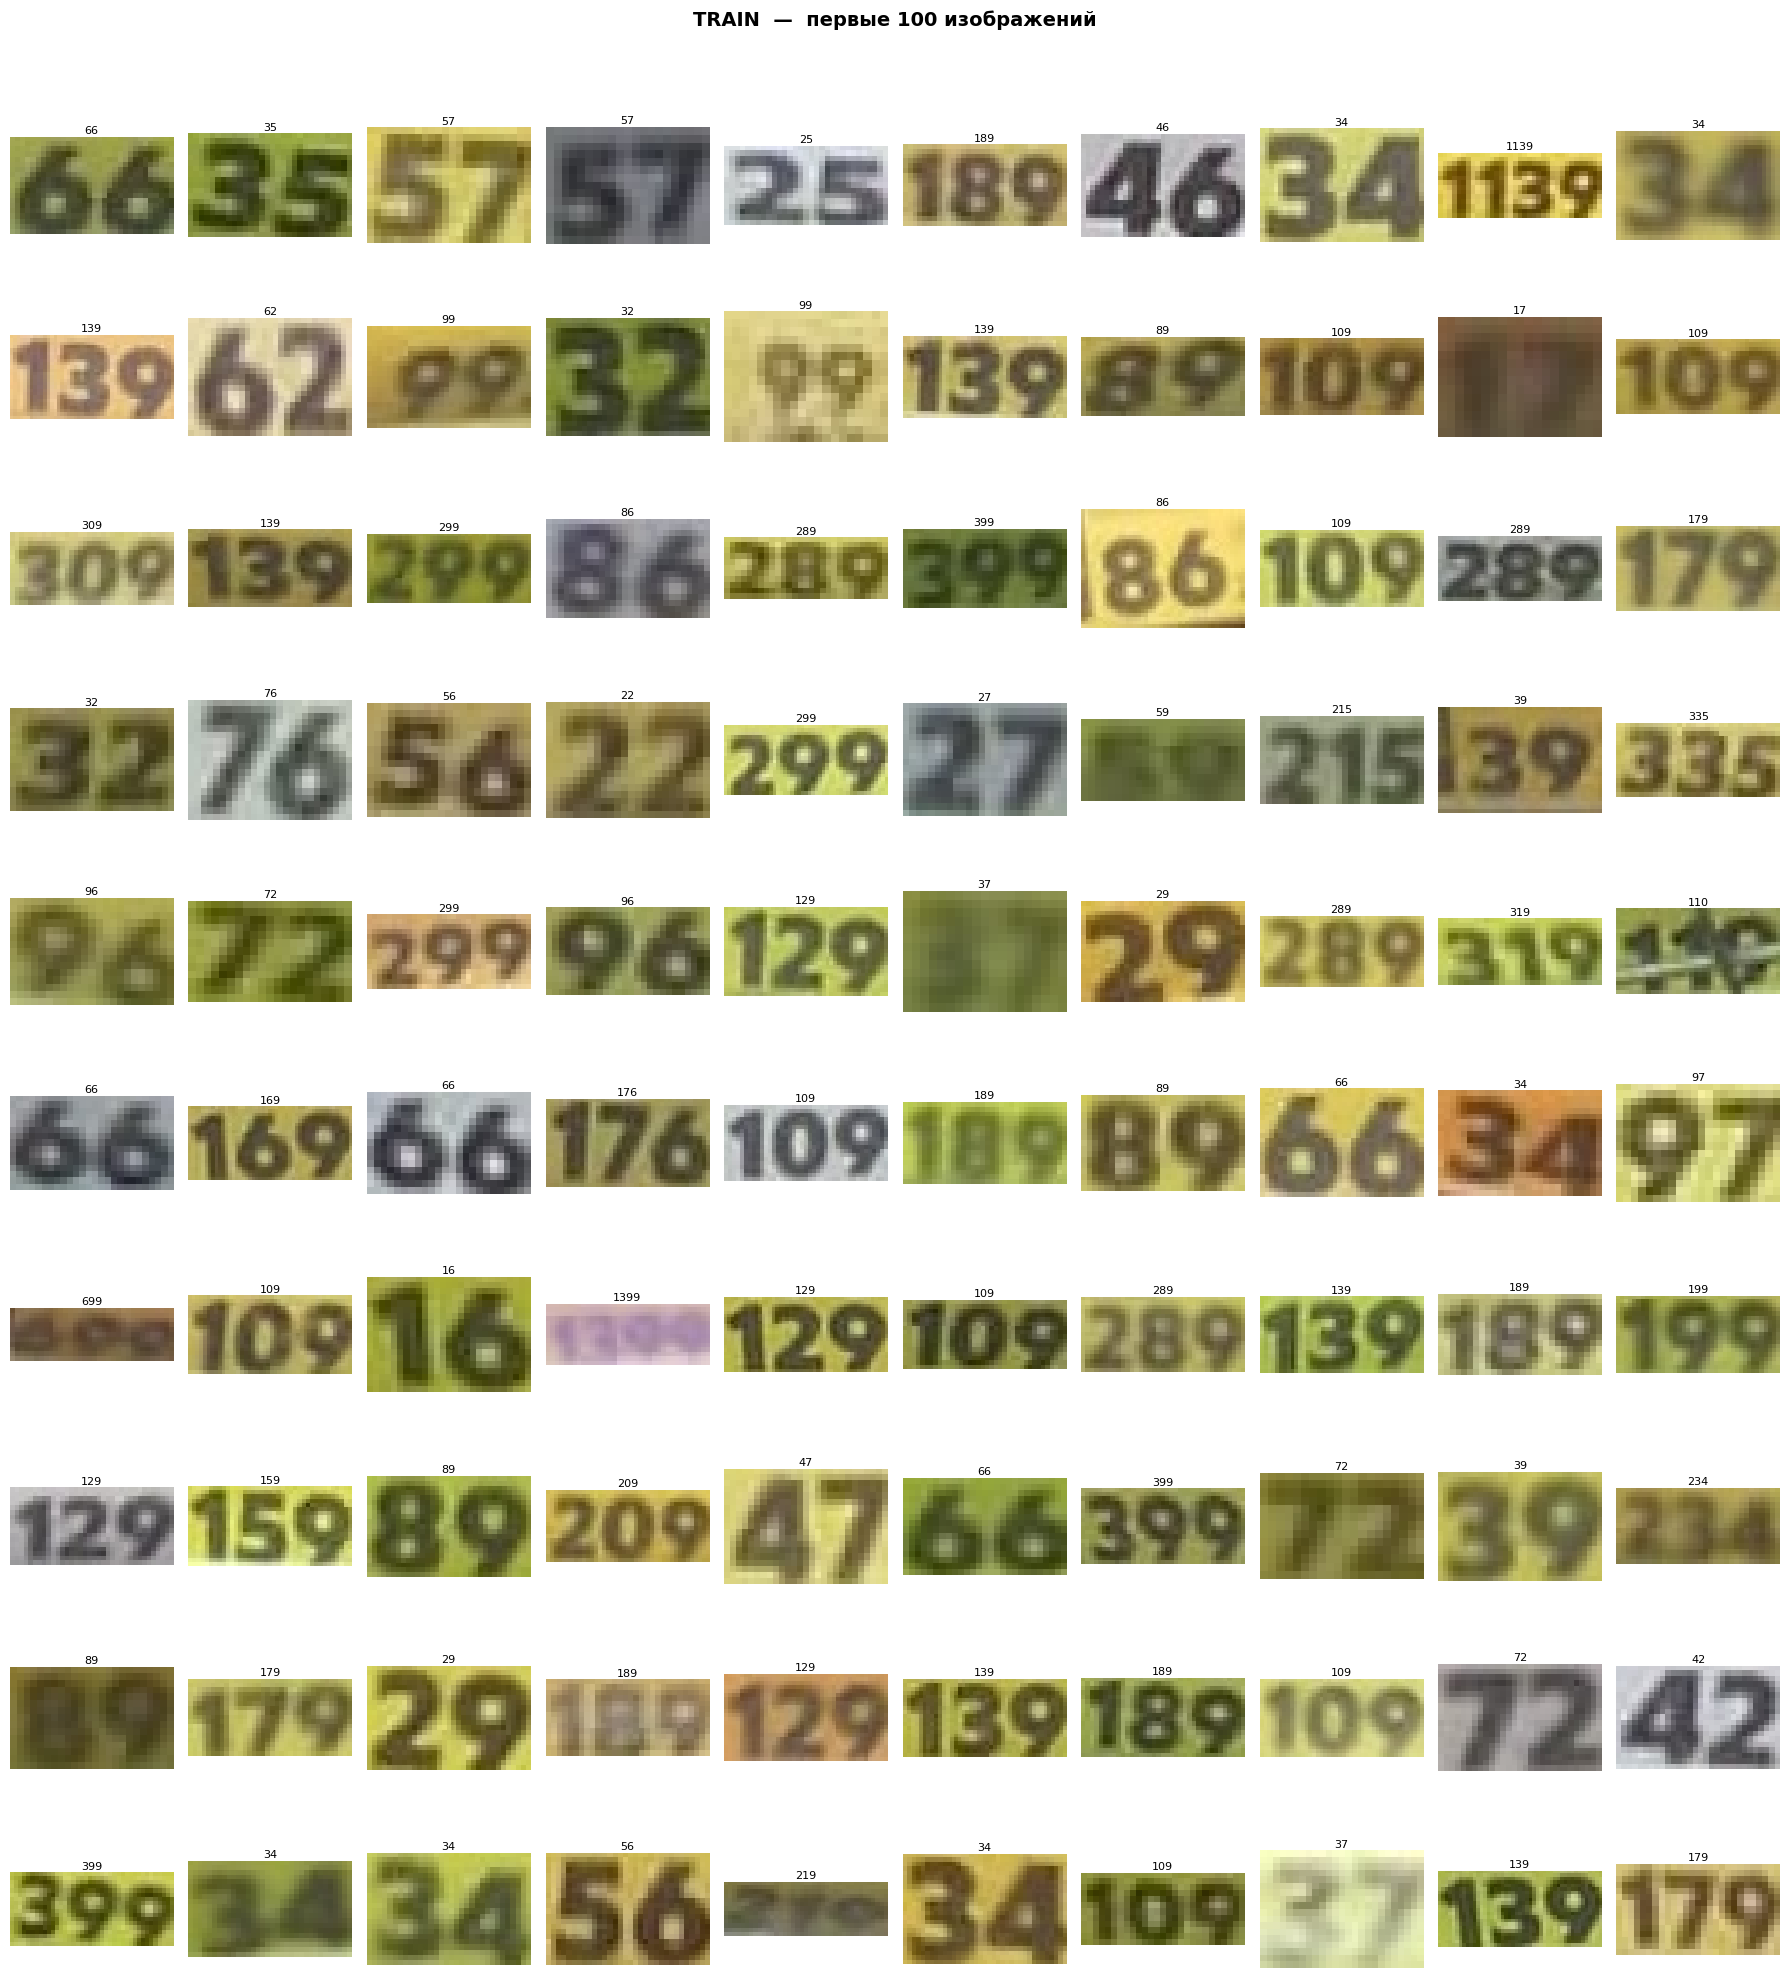

In [5]:
# ============================================================
# 1. ТРЕНИРОВОЧНЫЙ ДАТАСЕТ — сетка изображений
# ============================================================
print(">>> Загружаем train.csv ...")
train_df = pd.read_csv(TRAIN_CSV)

# Берём первые 100 записей для сетки
sample_train = train_df.head(100)
train_paths  = [os.path.join(TRAIN_DIR, f) for f in sample_train['Filename']]
train_labels = sample_train['Price'].tolist()

print(">>> Рисуем сетку тренировочных изображений ...")
plot_image_grid(train_paths, train_labels, tag='TRAIN')


>>> Собираем размеры тренировочных изображений (может занять минуту) ...

  Статистика размеров — TRAIN

  [width]
    Кол-во  : 15050
    Среднее : 33.7
    Медиана : 33.0
    Мин     : 12
    Макс    : 110
    75%     : 39.0
    95%     : 47.0

  [height]
    Кол-во  : 15050
    Среднее : 18.2
    Медиана : 18.0
    Мин     : 11
    Макс    : 82
    75%     : 20.0
    95%     : 24.0

  [pixels]
    Кол-во  : 15050
    Среднее : 633.9
    Медиана : 594.0
    Мин     : 168
    Макс    : 6396
    75%     : 782.0
    95%     : 1057.1


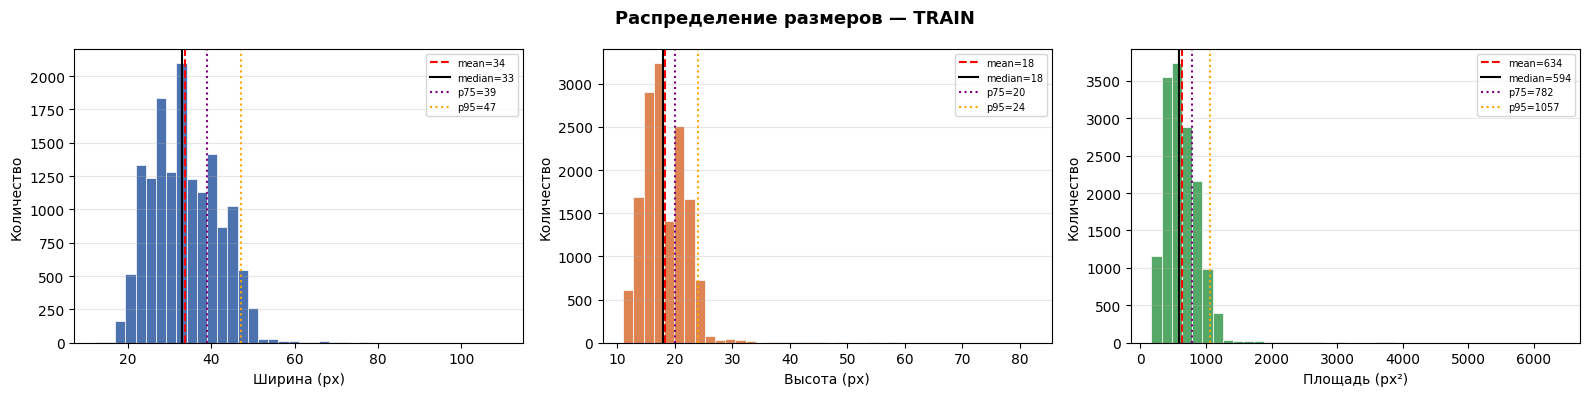

In [6]:
# ============================================================
# 2. ТРЕНИРОВОЧНЫЙ ДАТАСЕТ — статистика размеров
# ============================================================
print("\n>>> Собираем размеры тренировочных изображений (может занять минуту) ...")
train_sizes = collect_sizes(TRAIN_DIR)
print_size_stats(train_sizes, 'TRAIN')
plot_size_histograms(train_sizes, 'TRAIN')


>>> Рисуем сетку тестовых изображений ...


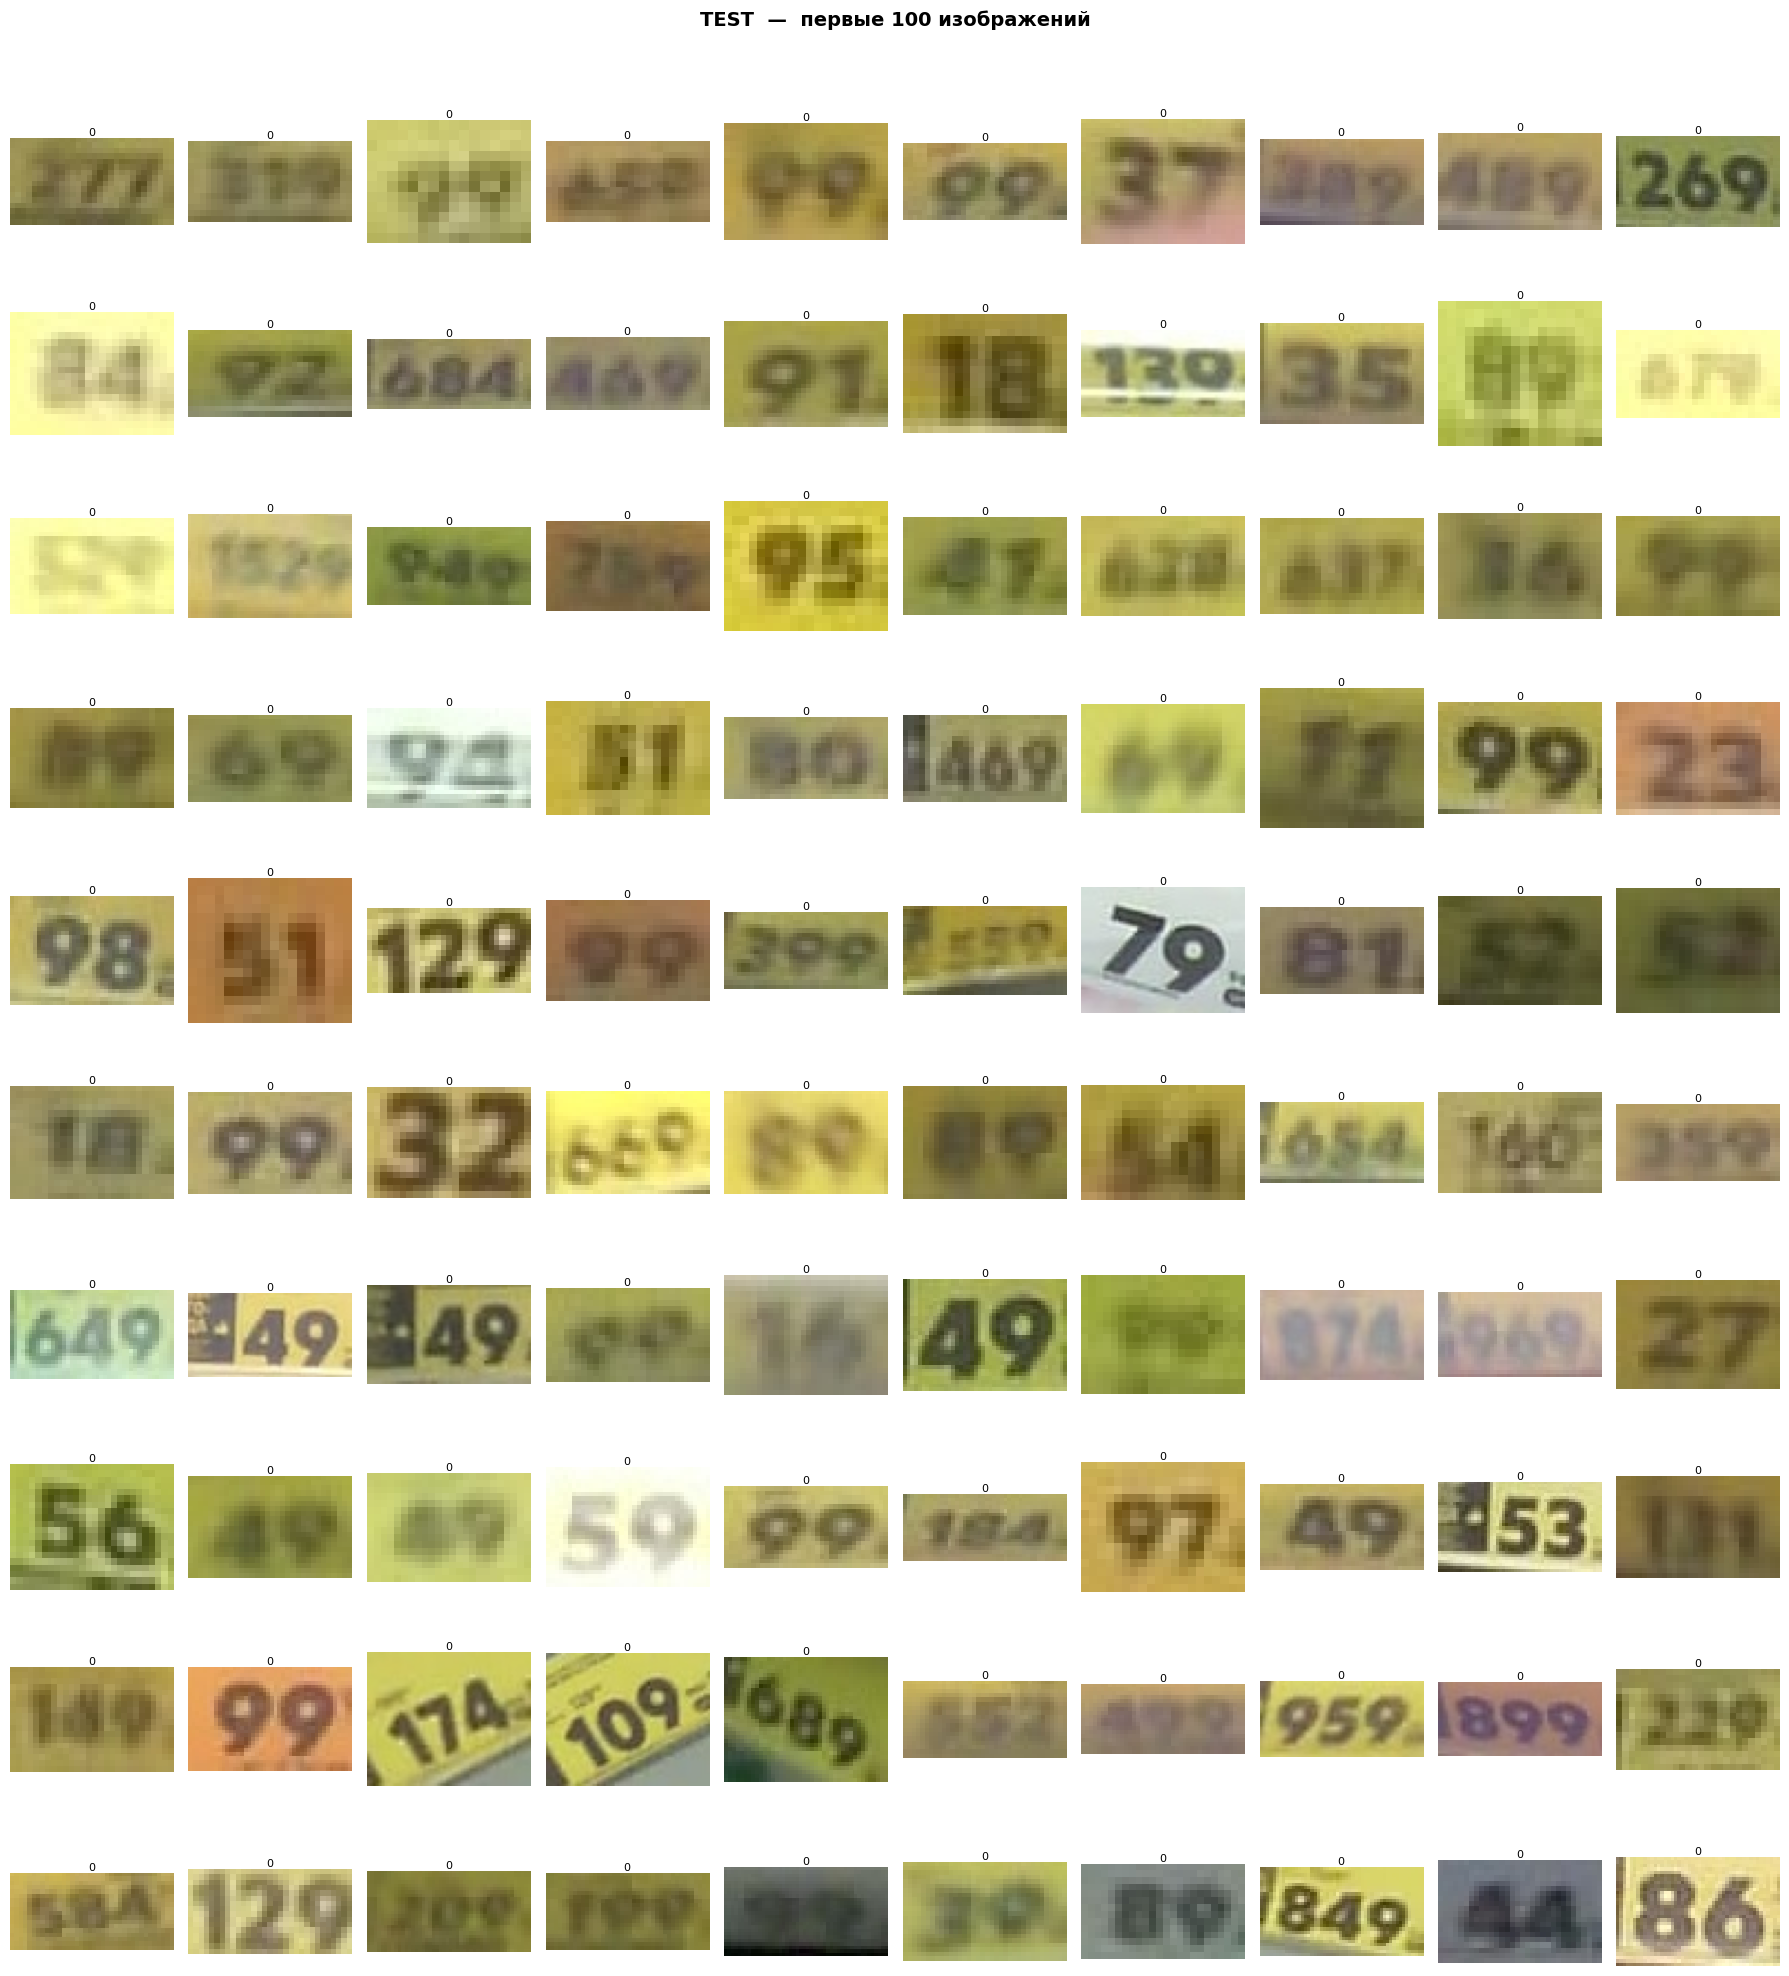

In [7]:
# ============================================================
# 3. ТЕСТОВЫЙ ДАТАСЕТ — сетка изображений
# ============================================================
test_files = sorted([f for f in os.listdir(TEST_DIR) if f.lower().endswith('.jpg')])
test_paths_100 = [os.path.join(TEST_DIR, f) for f in test_files[:100]]
test_titles    = [f.split('_')[0] for f in test_files[:100]]   # ID из имени файла

print("\n>>> Рисуем сетку тестовых изображений ...")
plot_image_grid(test_paths_100, test_titles, tag='TEST')


>>> Собираем размеры тестовых изображений ...

  Статистика размеров — TEST

  [width]
    Кол-во  : 3762
    Среднее : 34.1
    Медиана : 34.0
    Мин     : 12
    Макс    : 104
    75%     : 40.0
    95%     : 47.0

  [height]
    Кол-во  : 3762
    Среднее : 18.3
    Медиана : 18.0
    Мин     : 11
    Макс    : 102
    75%     : 21.0
    95%     : 24.0

  [pixels]
    Кол-во  : 3762
    Среднее : 645.8
    Медиана : 600.0
    Мин     : 192
    Макс    : 10608
    75%     : 782.0
    95%     : 1058.0


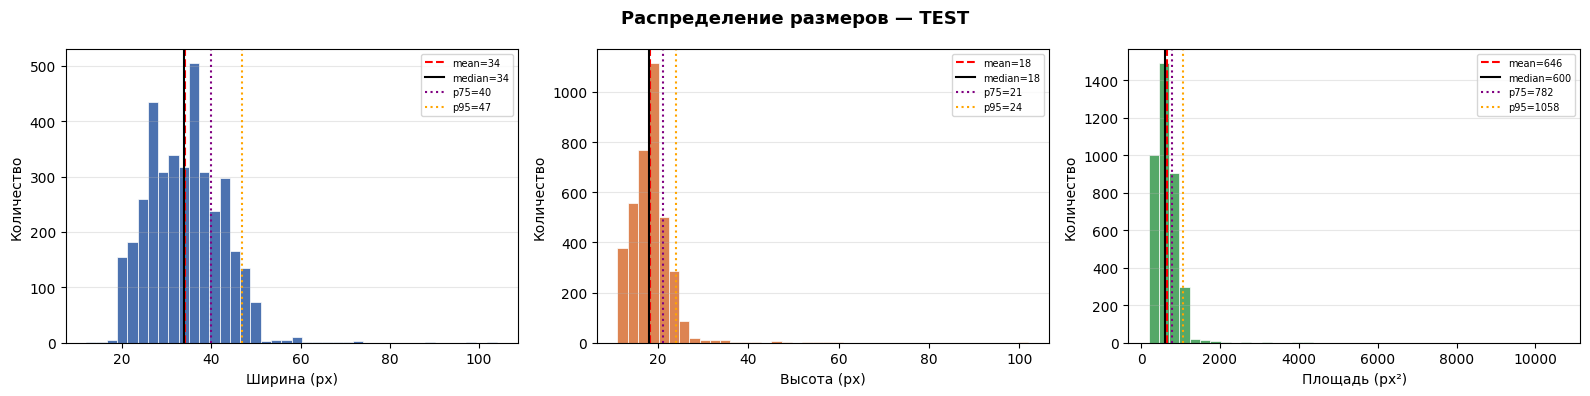

In [8]:
# ============================================================
# 4. ТЕСТОВЫЙ ДАТАСЕТ — статистика размеров
# ============================================================
print("\n>>> Собираем размеры тестовых изображений ...")
test_sizes = collect_sizes(TEST_DIR)
print_size_stats(test_sizes, 'TEST')
plot_size_histograms(test_sizes, 'TEST')


>>> Анализируем распределение цен ...


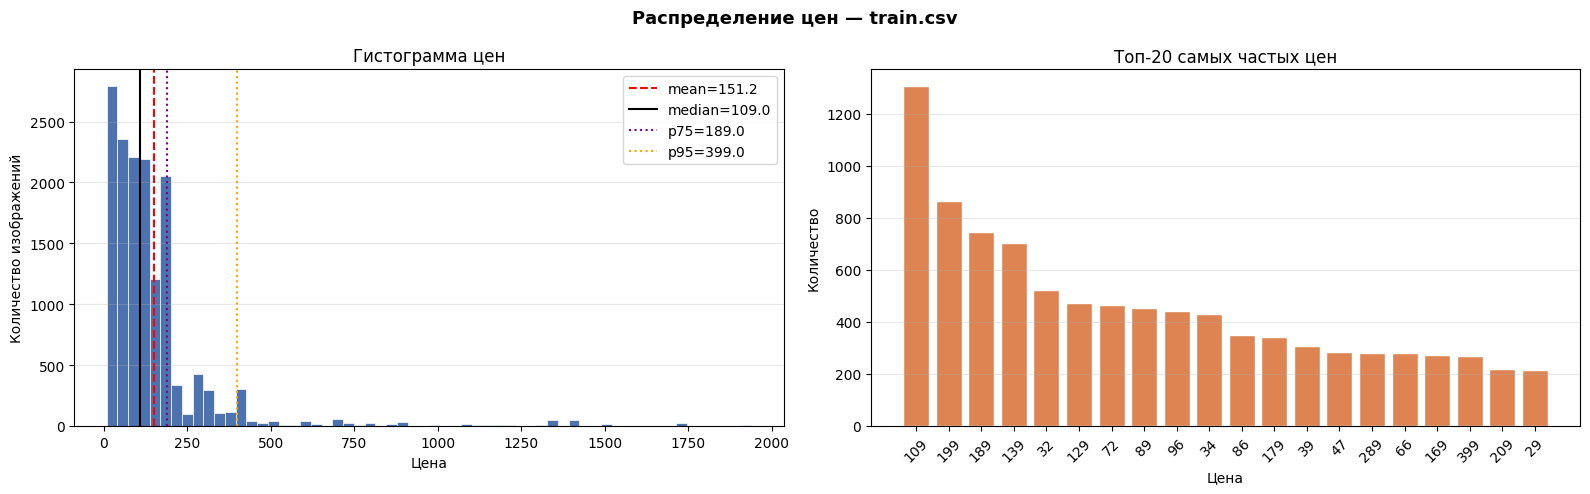


  Статистика цен — train.csv
  Записей всего    : 15050
  Уникальных цен   : 165
  Среднее          : 151.17
  Медиана          : 109.0
  Мин              : 9
  Макс             : 1939
  75%              : 189.0
  95%              : 399.0

  Топ-10 цен:
Price
109    1306
199     866
189     745
139     702
32      521
129     473
72      465
89      454
96      443
34      432


In [9]:
# ============================================================
# 5. РАСПРЕДЕЛЕНИЕ ЦЕН
# ============================================================
print("\n>>> Анализируем распределение цен ...")
plot_price_distribution(TRAIN_CSV)

In [29]:
# ============================================================
# ФИНАЛЬНЫЙ PIPELINE
# Global EQ → Median → Bilateral → Stretch → Unsharp
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [30]:
# ============================================================
# КОНФИГИ
# ============================================================
TRAIN_DIR = '/kaggle/input/competitions/dl-lab-4-ocr/train/train'
TRAIN_CSV = '/kaggle/input/competitions/dl-lab-4-ocr/train.csv'
N_IMAGES  = 10

In [161]:
# ============================================================
# ПАРАМЕТРЫ PIPELINE (меняй здесь)
# ============================================================
MEDIAN_KSIZE        = 3      # нечётное: 3, 5, 7

BILATERAL_D         = 5      # диаметр окрестности
BILATERAL_SIGMA_COLOR = 20   # порог по яркости (ниже = жёстче граница)
BILATERAL_SIGMA_SPACE = 10    # пространственное влияние

STRETCH_P_LOW       = 10      # нижний перцентиль обрезки (%)
STRETCH_P_HIGH      = 80     # верхний перцентиль обрезки (%)

UNSHARP_BLUR_KSIZE  = 5      # размер ядра размытия (нечётное)
UNSHARP_AMOUNT      = 2.0    # сила резкости (1.0 - 3.0)
UNSHARP_SIGMA       = 1.0    # sigma для гауссова размытия

# ============================================================
# УТИЛИТЫ
# ============================================================
def load_gray(filename: str, base_dir: str = TRAIN_DIR) -> np.ndarray:
    """Загружает изображение и конвертирует в grayscale."""
    path = os.path.join(base_dir, filename)
    img  = cv2.imdecode(np.fromfile(path, dtype=np.uint8), cv2.IMREAD_COLOR)
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [162]:
# ============================================================
# МЕТОДЫ PIPELINE
# ============================================================
def apply_global_eq(img: np.ndarray) -> np.ndarray:
    """
    Глобальная эквализация гистограммы.
    Растягивает гистограмму яркости на весь диапазон 0-255.
    """
    return cv2.equalizeHist(img)


def apply_median(img: np.ndarray,
                 ksize: int = MEDIAN_KSIZE) -> np.ndarray:
    """
    Медианный фильтр.
    Убирает точечный шум (соль и перец), сохраняет края.
    ksize — размер ядра, только нечётные числа.
    """
    return cv2.medianBlur(img, ksize)


def apply_bilateral(img: np.ndarray,
                    d: int           = BILATERAL_D,
                    sigma_color: int = BILATERAL_SIGMA_COLOR,
                    sigma_space: int = BILATERAL_SIGMA_SPACE) -> np.ndarray:
    """
    Билатеральный фильтр.
    Сглаживает фон, сохраняет чёткие границы цифр.
    d           — диаметр окрестности
    sigma_color — порог по яркости (ниже = жёстче граница цифра/фон)
    sigma_space — пространственное влияние соседей
    """
    return cv2.bilateralFilter(img, d, sigma_color, sigma_space)


def apply_contrast_stretch(img: np.ndarray,
                           p_low: float  = STRETCH_P_LOW,
                           p_high: float = STRETCH_P_HIGH) -> np.ndarray:
    """
    Линейное растяжение контраста по перцентилям.
    Значения ниже p_low  → 0   (чистый чёрный)
    Значения выше p_high → 255 (чистый белый)
    Остальное линейно растягивается между ними.
    p_low, p_high — перцентили обрезки в процентах.
    """
    p_lo = np.percentile(img, p_low)
    p_hi = np.percentile(img, p_high)

    if p_hi == p_lo:
        return img.copy()

    stretched = (img.astype(np.float32) - p_lo) / (p_hi - p_lo) * 255.0
    return np.clip(stretched, 0, 255).astype(np.uint8)


def apply_unsharp(img: np.ndarray,
                  blur_ksize: int = UNSHARP_BLUR_KSIZE,
                  amount: float   = UNSHARP_AMOUNT,
                  sigma: float    = UNSHARP_SIGMA) -> np.ndarray:
    """
    Unsharp Masking — усиление локального контраста на краях.
    Формула: out = original * (1 + amount) - blurred * amount
    blur_ksize — размер ядра размытия (нечётное)
    amount     — сила резкости (больше = резче, но больше артефактов)
    sigma      — sigma гауссова размытия
    """
    blurred   = cv2.GaussianBlur(img, (blur_ksize, blur_ksize), sigma)
    sharpened = cv2.addWeighted(img, 1 + amount, blurred, -amount, 0)
    return sharpened

In [163]:
# ============================================================
# ФИНАЛЬНЫЙ PIPELINE
# ============================================================
def preprocess(img: np.ndarray) -> dict:
    """
    Применяет финальный pipeline пошагово.
    Возвращает словарь со всеми промежуточными результатами.
    """
    steps = {}

    steps['1: Original']           = img.copy()
    steps['2: +Global EQ']         = apply_global_eq(steps['1: Original'])
    steps['3: +Median']            = apply_median(steps['2: +Global EQ'])
    steps['4: +Bilateral']         = apply_bilateral(steps['3: +Median'])
    steps['5: +Stretch']           = apply_contrast_stretch(steps['4: +Bilateral'])
    steps['6: +Unsharp']           = apply_unsharp(steps['5: +Stretch'])

    return steps


def get_final(img: np.ndarray) -> np.ndarray:
    """Возвращает только финальный результат pipeline."""
    return preprocess(img)['6: +Unsharp']

In [164]:
# ============================================================
# ЗАГРУЗКА ИЗОБРАЖЕНИЙ
# ============================================================
train_df    = pd.read_csv(TRAIN_CSV)
sample_df   = train_df.head(N_IMAGES)
images_gray = [load_gray(f) for f in sample_df['Filename']]
labels      = sample_df['Price'].tolist()

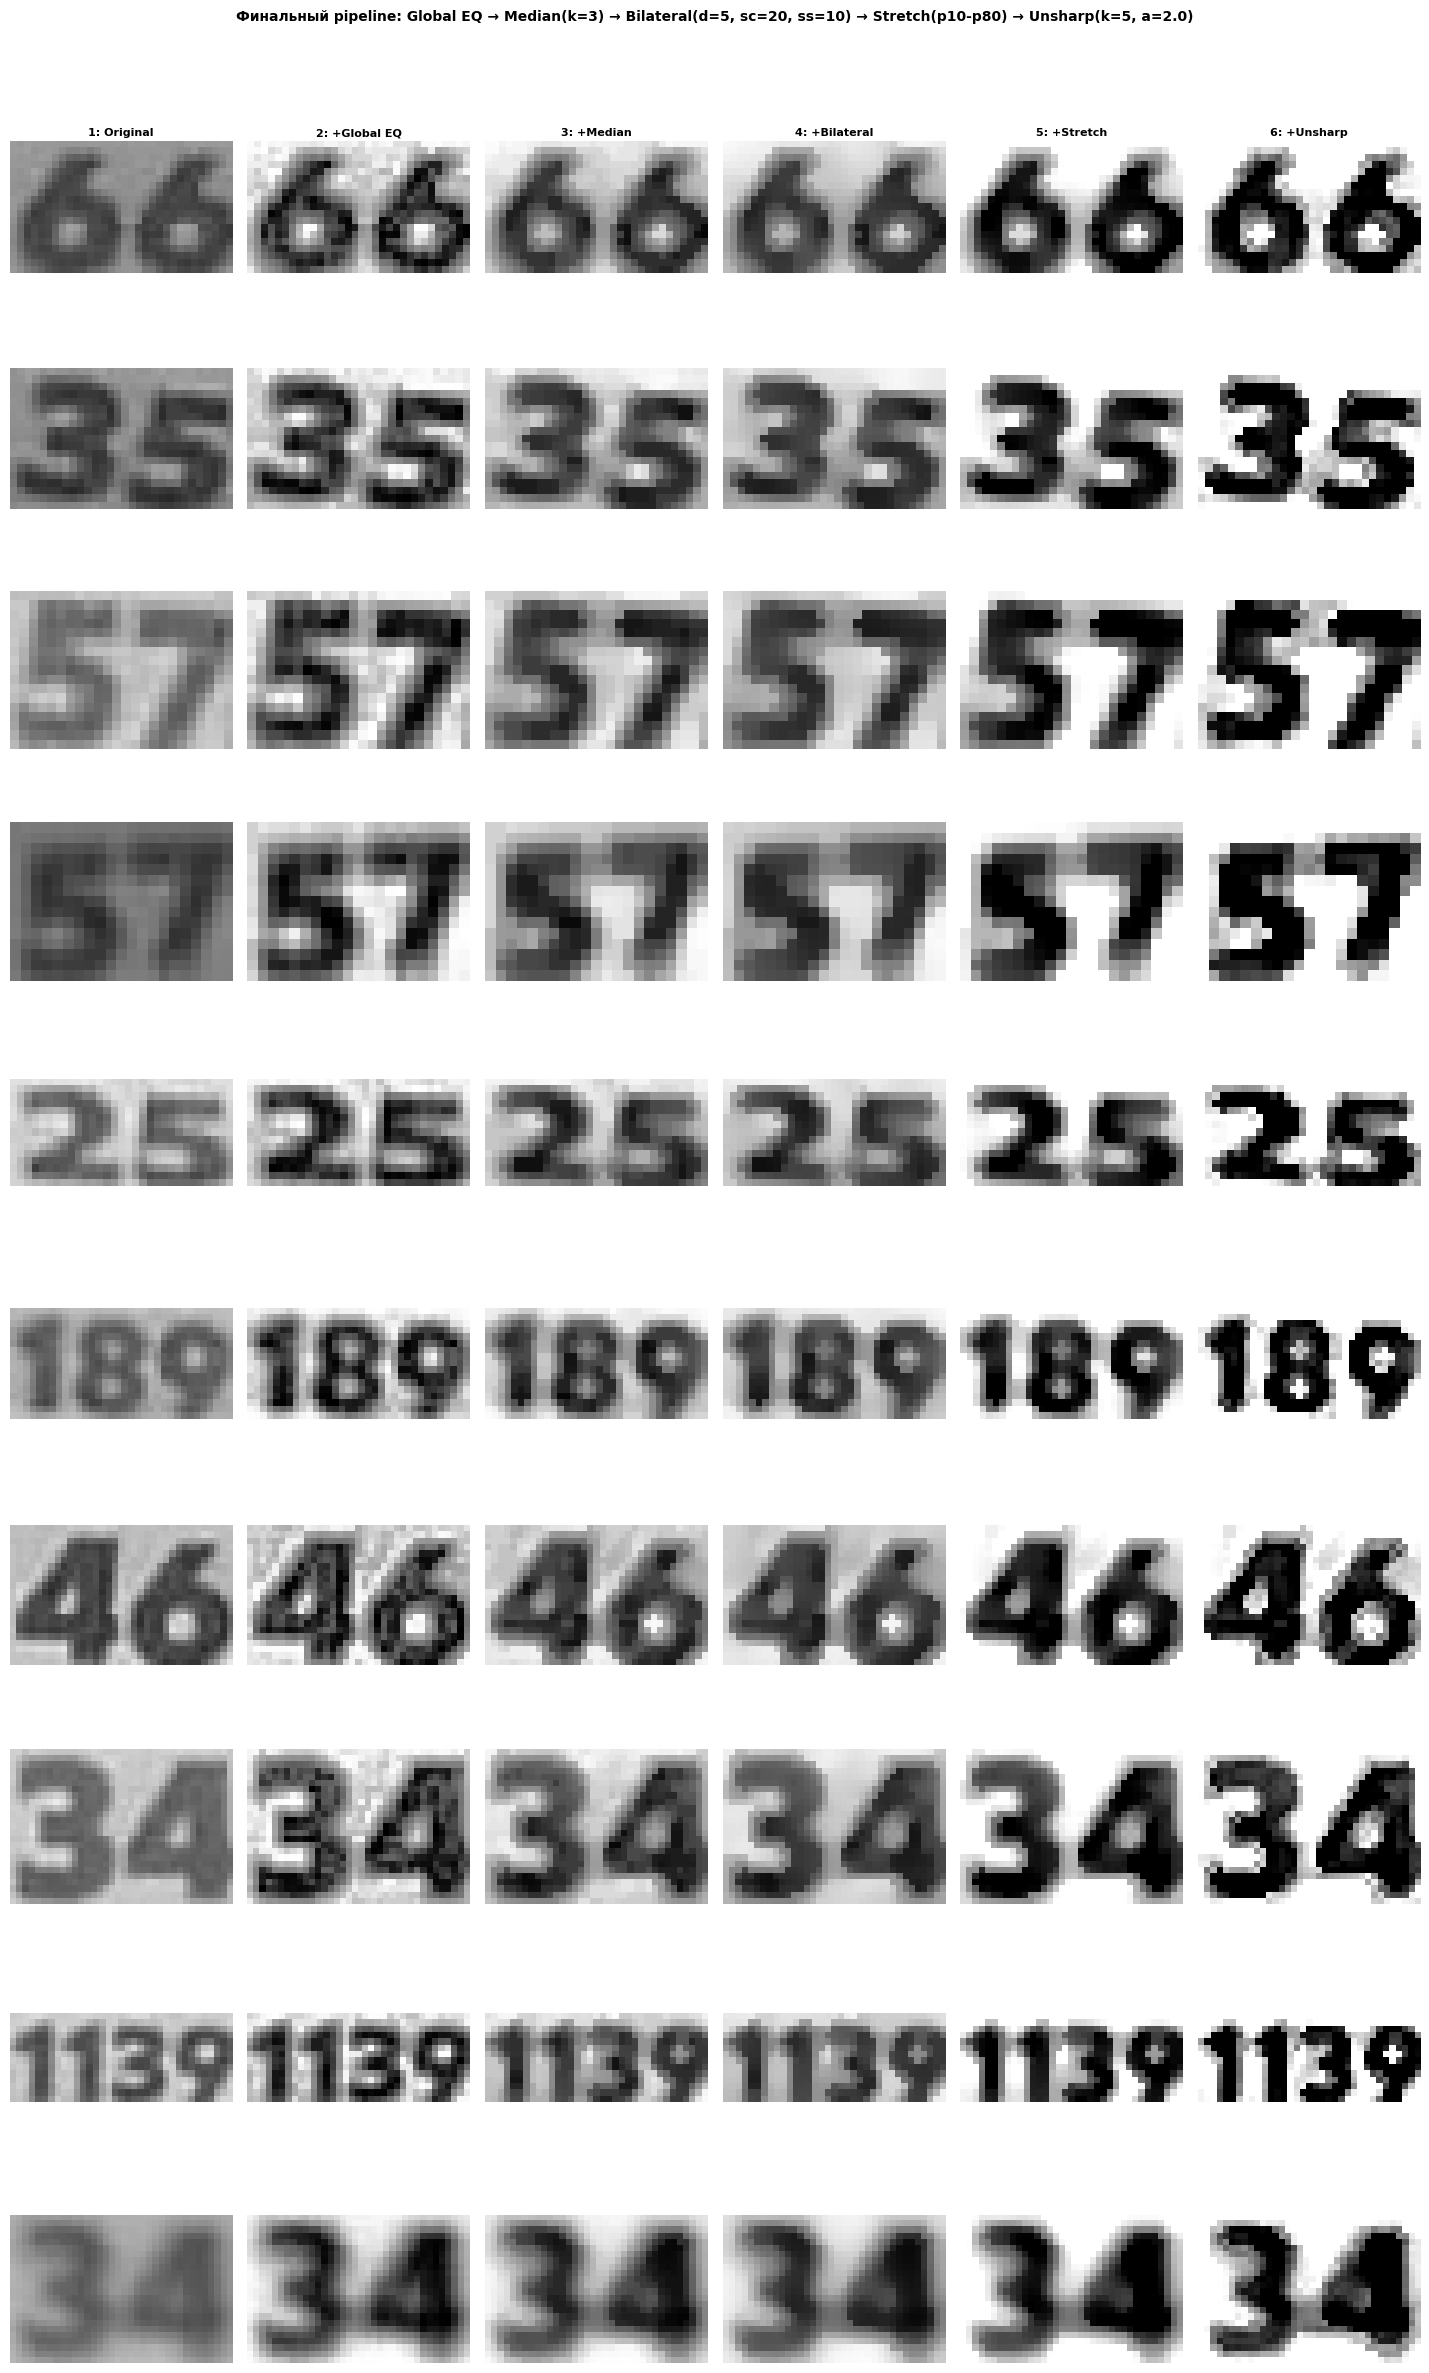

In [165]:
# ============================================================
# ВИЗУАЛИЗАЦИЯ
# ============================================================
n_rows = N_IMAGES
n_cols = 6

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.4, n_rows * 2.4))
fig.suptitle(
    f'Финальный pipeline: Global EQ → Median(k={MEDIAN_KSIZE}) → '
    f'Bilateral(d={BILATERAL_D}, sc={BILATERAL_SIGMA_COLOR}, ss={BILATERAL_SIGMA_SPACE}) → '
    f'Stretch(p{STRETCH_P_LOW}-p{STRETCH_P_HIGH}) → '
    f'Unsharp(k={UNSHARP_BLUR_KSIZE}, a={UNSHARP_AMOUNT})',
    fontsize=10, fontweight='bold', y=1.01
)

for row_idx, (img, label) in enumerate(zip(images_gray, labels)):
    steps = preprocess(img)

    for col_idx, (step_name, step_img) in enumerate(steps.items()):
        ax = axes[row_idx, col_idx]
        ax.imshow(step_img, cmap='gray', vmin=0, vmax=255)
        ax.axis('off')

        if row_idx == 0:
            ax.set_title(step_name, fontsize=8, fontweight='bold', pad=4)

        if col_idx == 0:
            ax.set_ylabel(f'Price: {label}', fontsize=8, rotation=0,
                          labelpad=55, va='center')

plt.tight_layout()
plt.show()

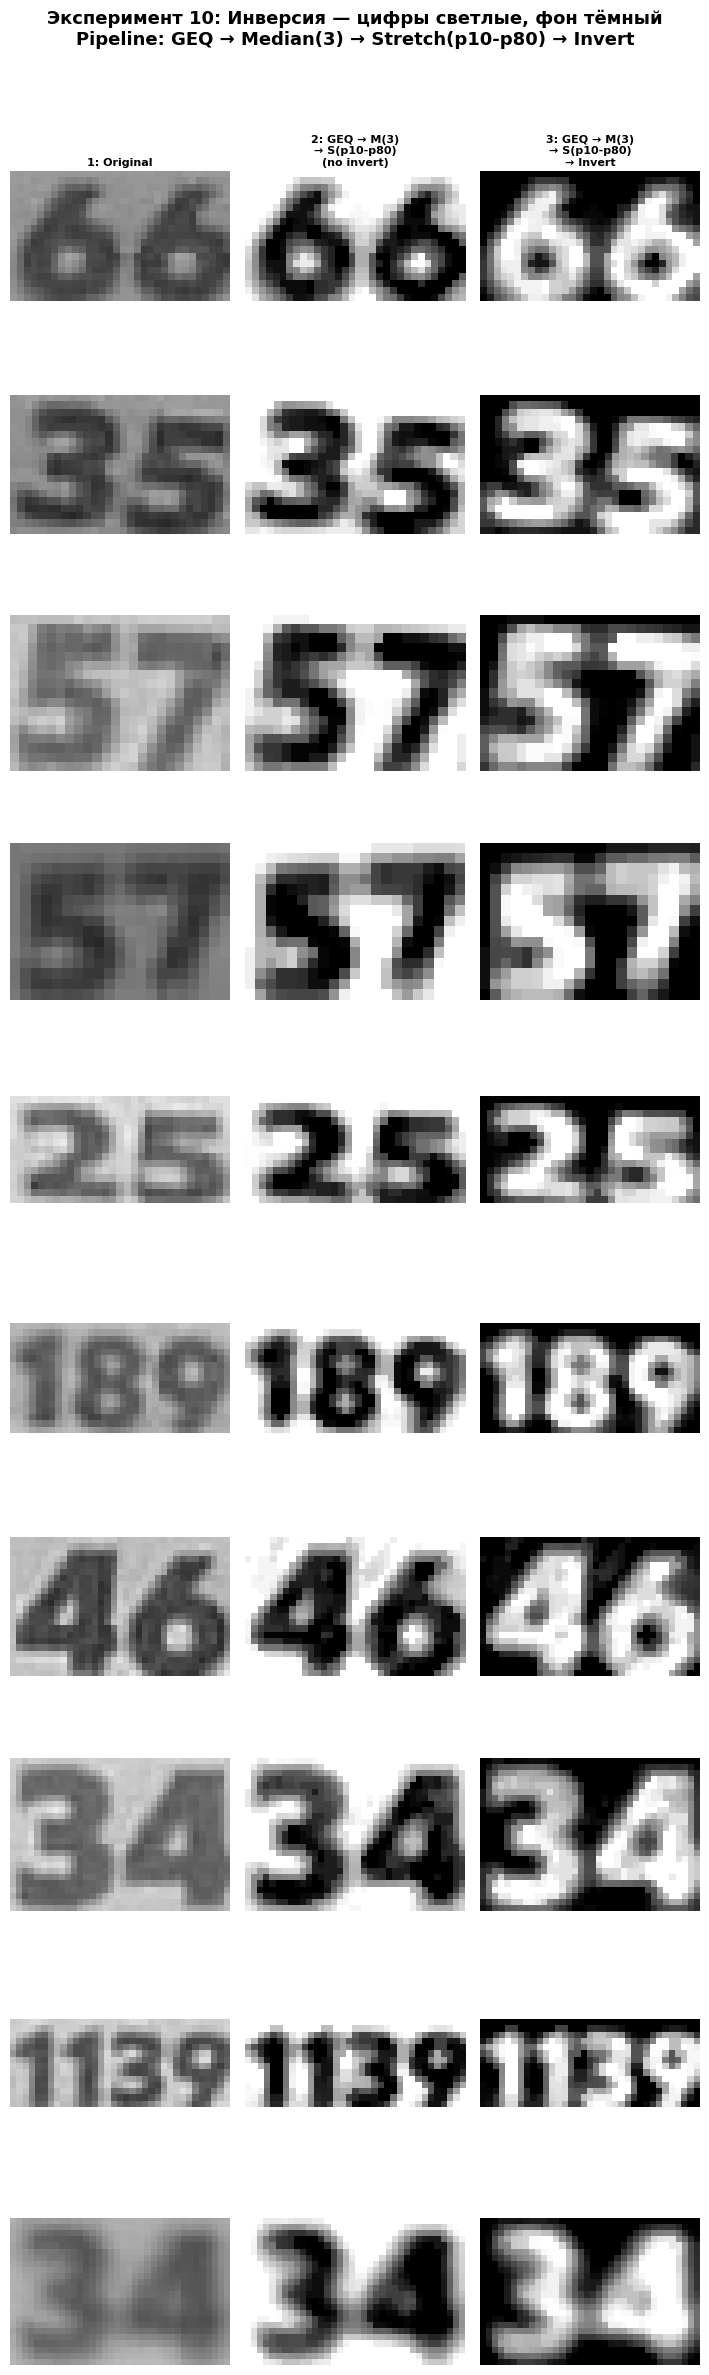


Финальный pipeline:
  1. Global Histogram Equalization
  2. Median Filter     : ksize=3
  3. Contrast Stretch  : p_low=10%, p_high=80%
  4. Invert            : out = 255 - img


In [167]:
# ============================================================
# ЭКСПЕРИМЕНТ 10
# Инверсия: цифры светлые (~255), фон тёмный (~0)
#
# Столбцы:
#   1. Оригинал
#   2. После pipeline (Global EQ → Median → Stretch)
#   3. Pipeline → Invert
# ============================================================

MEDIAN_KSIZE   = 3
STRETCH_P_LOW  = 10
STRETCH_P_HIGH = 80


def apply_invert(img: np.ndarray) -> np.ndarray:
    """
    Инверсия пикселей: out = 255 - img
    Цифры тёмные (~0)   → светлые (~255)
    Фон светлый (~255)  → тёмный (~0)
    """
    return cv2.bitwise_not(img)


def preprocess_v3(img: np.ndarray) -> np.ndarray:
    """
    Финальный pipeline:
    Global EQ → Median → Contrast Stretch → Invert
    """
    step1 = apply_global_eq(img)
    step2 = apply_median(step1, ksize=MEDIAN_KSIZE)
    step3 = apply_contrast_stretch(step2, p_low=STRETCH_P_LOW, p_high=STRETCH_P_HIGH)
    step4 = apply_invert(step3)
    return step4


experiment_10_columns = [
    (
        '1: Original',
        lambda img: img.copy()
    ),
    (
        '2: GEQ → M(3)\n→ S(p10-p80)\n(no invert)',
        lambda img: preprocess_v2(img)
    ),
    (
        '3: GEQ → M(3)\n→ S(p10-p80)\n→ Invert',
        lambda img: preprocess_v3(img)
    ),
]

plot_experiment(
    images_gray = images_gray,
    labels      = labels,
    columns     = experiment_10_columns,
    title       = f'Эксперимент 10: Инверсия — цифры светлые, фон тёмный\n'
                  f'Pipeline: GEQ → Median({MEDIAN_KSIZE}) → Stretch(p{STRETCH_P_LOW}-p{STRETCH_P_HIGH}) → Invert'
)

print("\nФинальный pipeline:")
print(f"  1. Global Histogram Equalization")
print(f"  2. Median Filter     : ksize={MEDIAN_KSIZE}")
print(f"  3. Contrast Stretch  : p_low={STRETCH_P_LOW}%, p_high={STRETCH_P_HIGH}%")
print(f"  4. Invert            : out = 255 - img")